Pseudobulking single cell objects

In [1]:
import decoupler as dc
import matplotlib as plt
import seaborn as sns
import scanpy as sc

C:\Users\nateh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
organoids = sc.read_h5ad('C:/Users/nateh/OneDrive/Documents/Mei Lab/RNAseq/scRNAseq/Integrated Datasets/3 + 4 cell type organoids/Scanpy/Integrated_Organoid_Object_filtered_simpleannotations.h5ad')

C:\Users\nateh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\anndata\_core\anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [3]:
organoids.obs
organoids

AnnData object with n_obs × n_vars = 22452 × 3797
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'batch', 'organoid_type', 'cell_type'
    uns: 'batch_colors', 'leiden', 'leiden_colors', 'neighbors', 'organoid_type_colors', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

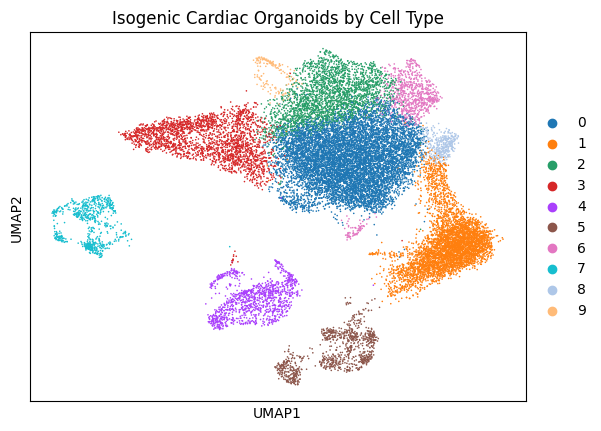

In [8]:
import scanpy as sc

color_mapping = {
    'Cardiomyocytes': '#d62728',  #Red
    'Cardiac Fibroblasts': '#800080', #Purple
    'Endothelial Cells': '#528AAE',  # Blue
    'Pericytes': '#008000',  # Green
}

# Plot UMAP with custom colors
sc.pl.umap(
    organoids,
    color='leiden',
    #palette=color_mapping,
    title='Isogenic Cardiac Organoids by Cell Type',
    alpha=1.0
)


In [14]:
simple_cells = {'0':'Cardiomyocytes',
                '1':'Cardiomyocytes',
                '2':'Cardiomyocytes',
                '3':'Cardiomyocytes',
                '4': 'Pericytes',
                '5': 'Cardiac Fibroblasts',
                '6': 'Cardiomyocytes',
                '7': 'Endothelial Cells',
                '8': 'Cardiomyocytes',
                '9': 'Cardiomyocytes'}

In [16]:
organoids.obs['cell_type'] = organoids.obs['leiden'].map(simple_cells)


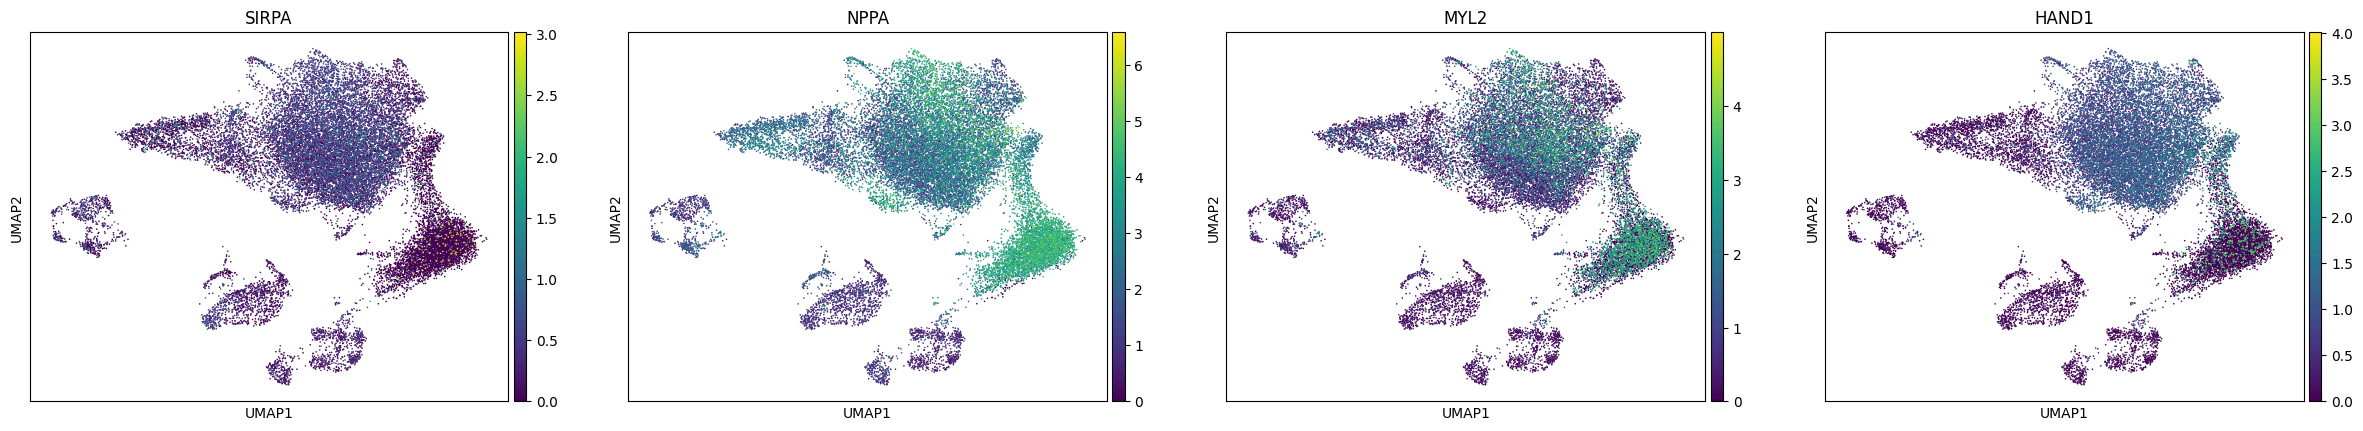

In [80]:
sc.pl.umap(organoids, color=['SIRPA', 'NPPA','MYL2','HAND1'])

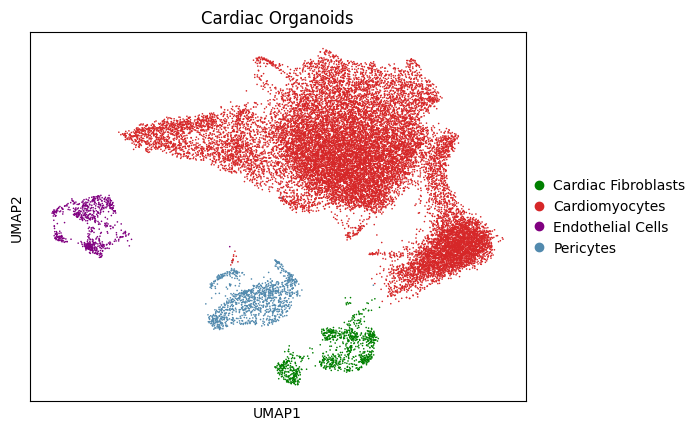

In [59]:
import scanpy as sc

color_mapping = {
    'Cardiomyocytes': '#d62728',  #Red
    'Endothelial Cells': '#800080', #Purple
    'Pericytes': '#528AAE',  # Blue
    'Cardiac Fibroblasts': '#008000',  # Green
}

# Plot UMAP with custom colors
sc.pl.umap(
    organoids,
    color='cell_type',
    palette=color_mapping,
    title='Cardiac Organoids',
    alpha=1.0
)


C:\Users\nateh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\scanpy\plotting\_utils.py:491: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
C:\Users\nateh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\anndata\_core\anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
C:\Users\nateh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\anndata\_core\anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
C:\Users\nateh\AppData\Local\Packages\PythonSoftwareFoundation.

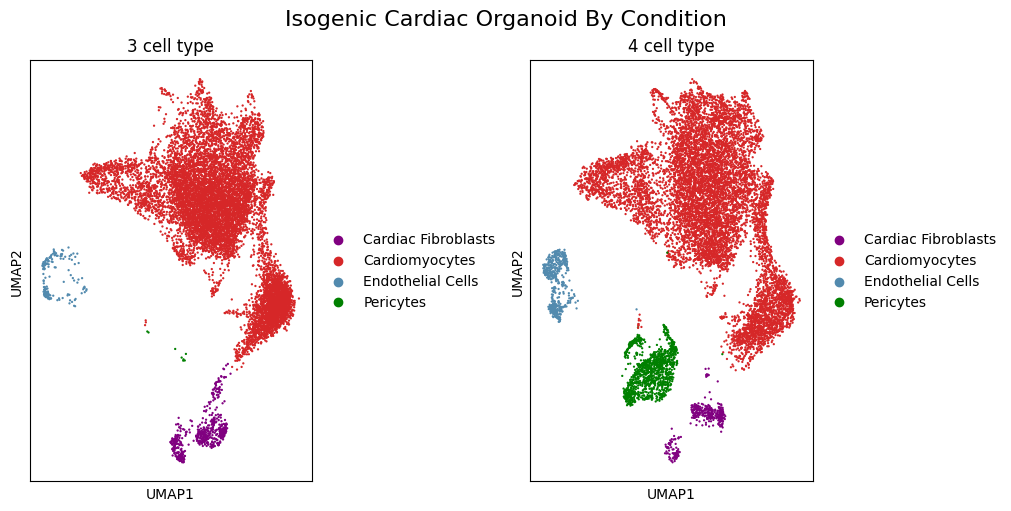

In [19]:
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

# Define the condition column
condition_col = 'organoid_type'

# Get unique conditions
unique_conditions = organoids.obs[condition_col].unique()
num_conditions = len(unique_conditions)

color_mapping = {
    'Cardiomyocytes': '#d62728',  #Red
    'Cardiac Fibroblasts': '#800080', #Purple
    'Endothelial Cells': '#528AAE',  # Blue
    'Pericytes': '#008000',  # Green
}

# Create subplots
fig, axes = plt.subplots(1, num_conditions, figsize=(5 * num_conditions, 5), constrained_layout=True)

# If only one condition, axes may not be iterable
if num_conditions == 1:
    axes = [axes]

# Loop through each condition and plot on its respective axis
for ax, condition in zip(axes, unique_conditions):
    subset = organoids[organoids.obs[condition_col] == condition]
    sc.pl.umap(
        subset,
        color='cell_type',
        palette=color_mapping,
        title=f'{condition}',
        ax=ax,
        show=False
    )

# Display the combined plot
plt.suptitle('Isogenic Cardiac Organoid By Condition', fontsize=16)
plt.show()


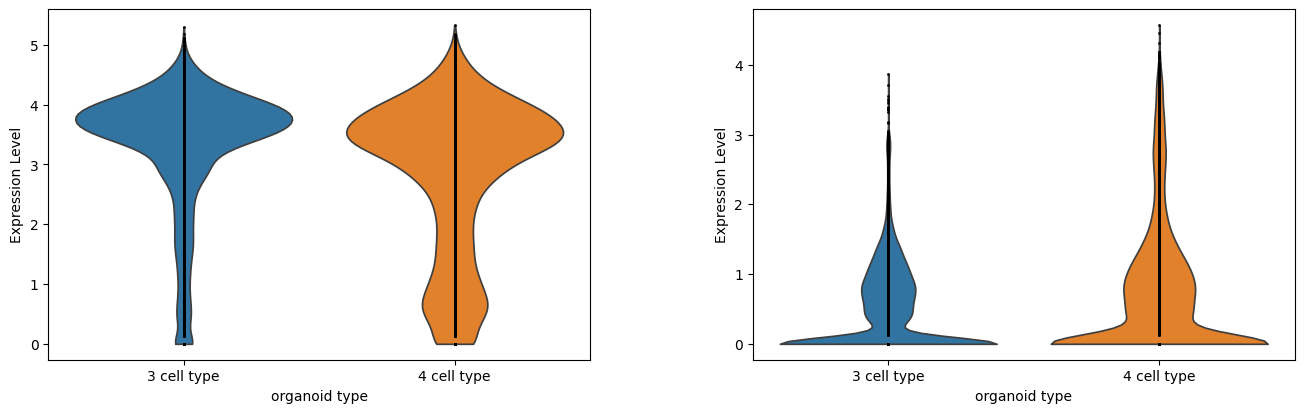

In [7]:
import scanpy as sc

# Define the marker genes of interest
marker_genes = ['TNNI1', 'RGS5']  # Replace with your genes

# Define the grouping variable (e.g., 'condition')
grouping_var = 'organoid_type'

# Generate violin plots
sc.pl.violin(
    organoids, 
    keys=marker_genes, 
    groupby=grouping_var,
    size=2, 
    scale='width', 
    stripplot=True, 
    jitter=False,
    multi_panel=True,
    ylabel='Expression Level',
    show=True
)


In [21]:
import numpy as np
import pandas as pd
import pybiomart as bm

In [9]:
#annot = sc.queries.biomart_annotations("hsapiens",
#        ["ensembl_gene_id", "external_gene_name"],
#        use_cache=False
#    ).set_index("ensembl_gene_id")
#organoids = organoids[:, organoids.var.index.intersection(annot.index)]

In [10]:
# Assign gene symbols
#organoids.var['gene_symbol'] = [annot.loc[ensembl_id,'external_gene_name'] for ensembl_id in organoids.var.index]
#organoids.var = organoids.var.reset_index().rename(columns={'index': 'ensembl_gene_id'}).set_index('gene_symbol')

In [11]:
# Convert adata.obs index to strings
#organoids.obs.index = organoids.obs.index.astype(str)

# Convert adata.var index to strings
#organoids.var.index = organoids.var.index.astype(str)

In [22]:
# Remove genes with no gene symbol
organoids = organoids[:, ~pd.isnull(organoids.var.index)]

# Remove duplicates
organoids.var_names_make_unique()

C:\Users\nateh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\anndata\_core\anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
C:\Users\nateh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\anndata\_core\anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [23]:
# Store raw counts in layers
organoids.X = np.round(organoids.X)
organoids.layers['counts'] = organoids.X

# Normalize and log-transform
sc.pp.normalize_total(organoids, target_sum=1e4)
sc.pp.log1p(organoids)
organoids.layers['normalized'] = organoids.X

C:\Users\nateh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\scanpy\preprocessing\_normalization.py:235: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))
C:\Users\nateh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\scanpy\preprocessing\_simple.py:387: RuntimeWarning: divide by zero encountered in log1p
  np.log1p(X, out=X)
C:\Users\nateh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\scanpy\preprocessing\_simple.py:387: RuntimeWarning: invalid value encountered in log1p
  np.log1p(X, out=X)


In [24]:
import numpy as np

# For dense matrices
if isinstance(organoids.X, np.ndarray):
    organoids.X[np.isnan(organoids.X)] = 0
    organoids.X[np.isinf(organoids.X)] = 0
else:
    # For sparse matrices, modify the data attribute
    organoids.X.data[np.isnan(organoids.X.data)] = 0
    organoids.X.data[np.isinf(organoids.X.data)] = 0


In [25]:
if 'counts' in organoids.layers:
    counts_data = organoids.layers['counts']
    print("Shape of 'counts' layer:", counts_data.shape)
    print("Data type of 'counts' layer:", counts_data.dtype)
    
    # Check for float values
    float_counts = np.any(counts_data != counts_data.astype(int))
    if float_counts:
        print("The 'counts' layer contains float values.")
    else:
        print("The 'counts' layer contains only integer values.")
else:
    print("The 'counts' layer does not exist in the organoids object.")

Shape of 'counts' layer: (22452, 3797)
Data type of 'counts' layer: float32
The 'counts' layer contains float values.


In [26]:
# Ensure that conversion is appropriate
if float_counts:
    organoids.layers['counts'] = organoids.layers['counts'].astype(int)
    print("Converted 'counts' layer to integers.")


Converted 'counts' layer to integers.


In [27]:
# Get pseudo-bulk profile
pdata = dc.get_pseudobulk(
    organoids,
    sample_col='batch',
    groups_col='cell_type',
    layer='counts',
    mode='sum',
    min_cells=0,
    min_counts=0
)

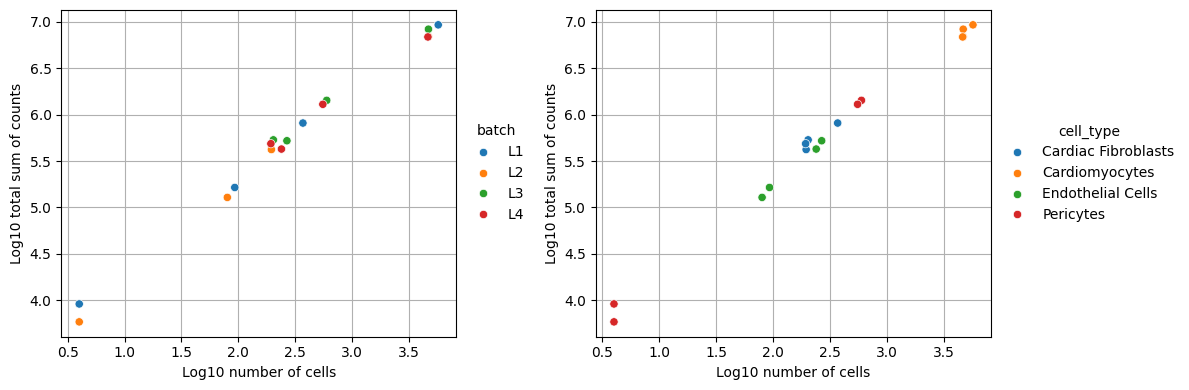

In [28]:
dc.plot_psbulk_samples(pdata, groupby=['batch', 'cell_type'], figsize=(12, 4))


In [29]:
# Get filtered pseudo-bulk profile
pdata = dc.get_pseudobulk(
    organoids,
    sample_col='batch',
    groups_col='cell_type',
    layer='counts',
    mode='sum',
    min_cells=10,
    min_counts=1000
)
pdata

AnnData object with n_obs × n_vars = 14 × 3797
    obs: 'batch', 'cell_type', 'organoid_type', 'psbulk_n_cells', 'psbulk_counts'
    layers: 'psbulk_props'

In [49]:
matrix = pdata.X.toarray() if hasattr(pdata.X,'toarray') else pdata.X

In [53]:
df = pd.DataFrame(matrix, index=pdata.obs_names, columns=pdata.var_names)
df = df.T

In [55]:
df.to_csv('C:/Users/nateh/OneDrive/Documents/Mei Lab/RNAseq/UDET Project/in silico/scpseudobulkdf.csv')

In [33]:
pdata.obs

,batch,cell_type,organoid_type,psbulk_n_cells,psbulk_counts
L1_Cardiac Fibroblasts,L1,Cardiac Fibroblasts,3 cell type,369.0,812310.0
L2_Cardiac Fibroblasts,L2,Cardiac Fibroblasts,3 cell type,195.0,420577.0
L3_Cardiac Fibroblasts,L3,Cardiac Fibroblasts,4 cell type,203.0,534724.0
L4_Cardiac Fibroblasts,L4,Cardiac Fibroblasts,4 cell type,193.0,486454.0
L1_Cardiomyocytes,L1,Cardiomyocytes,3 cell type,5697.0,9309169.0
L2_Cardiomyocytes,L2,Cardiomyocytes,3 cell type,4661.0,6965271.0
L3_Cardiomyocytes,L3,Cardiomyocytes,4 cell type,4674.0,8358093.0
L4_Cardiomyocytes,L4,Cardiomyocytes,4 cell type,4624.0,6892167.0
L1_Endothelial Cells,L1,Endothelial Cells,3 cell type,93.0,163931.0
L2_Endothelial Cells,L2,Endothelial Cells,3 cell type,80.0,128046.0


In [34]:
# Store raw counts in layers
pdata.layers['counts'] = pdata.X.copy()

# Normalize, scale and compute pca
sc.pp.normalize_total(pdata, target_sum=1e4)
sc.pp.log1p(pdata)
sc.pp.scale(pdata, max_value=10)
sc.tl.pca(pdata)

# Return raw counts to X
dc.swap_layer(pdata, 'counts', X_layer_key=None, inplace=True)

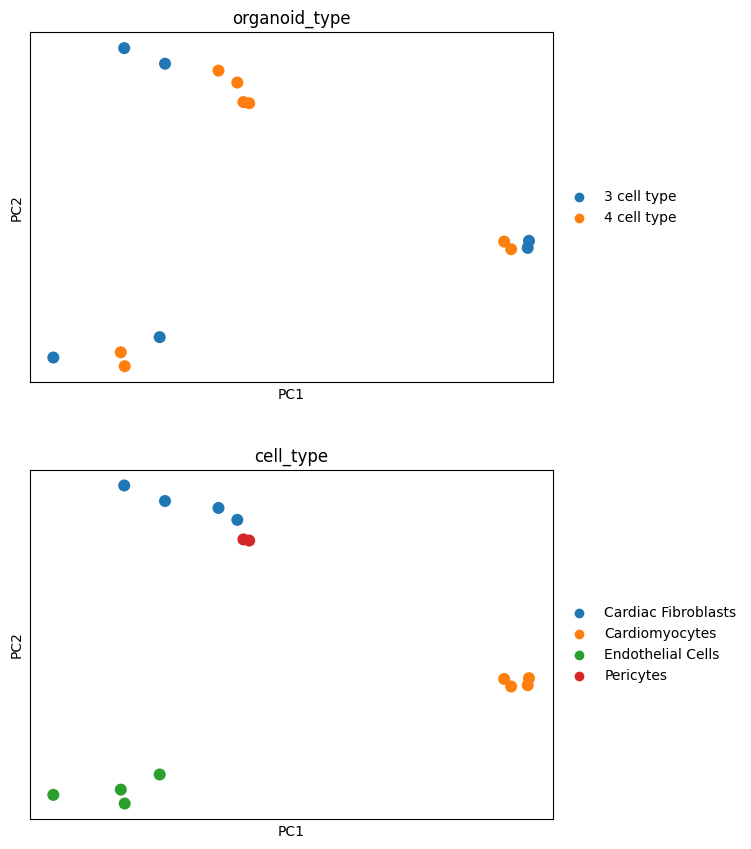

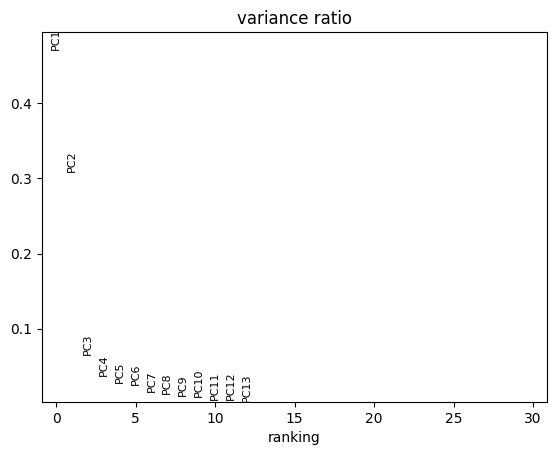

In [35]:
sc.pl.pca(pdata, color=['organoid_type', 'cell_type'], ncols=1, size=300)
sc.pl.pca_variance_ratio(pdata)

Organoid Type (i.e., 3 vs 4 cell type organoids) do not seem to have significant impacts, however we will delve further into the meta data of the PC loadings, as PC1 and PC2 explain most of the variance.

In [36]:
pdata

AnnData object with n_obs × n_vars = 14 × 3797
    obs: 'batch', 'cell_type', 'organoid_type', 'psbulk_n_cells', 'psbulk_counts'
    var: 'mean', 'std'
    uns: 'log1p', 'pca', 'organoid_type_colors', 'cell_type_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'psbulk_props', 'counts'

In [37]:
dc.get_metadata_associations(
    pdata,
    obs_keys = ['batch', 'cell_type', 'organoid_type','psbulk_n_cells', 'psbulk_counts'],  # Metadata columns to associate to PCs
    obsm_key='X_pca',  # Where the PCs are stored
    uns_key='pca_anova',  # Where the results are stored
    inplace=True,
)

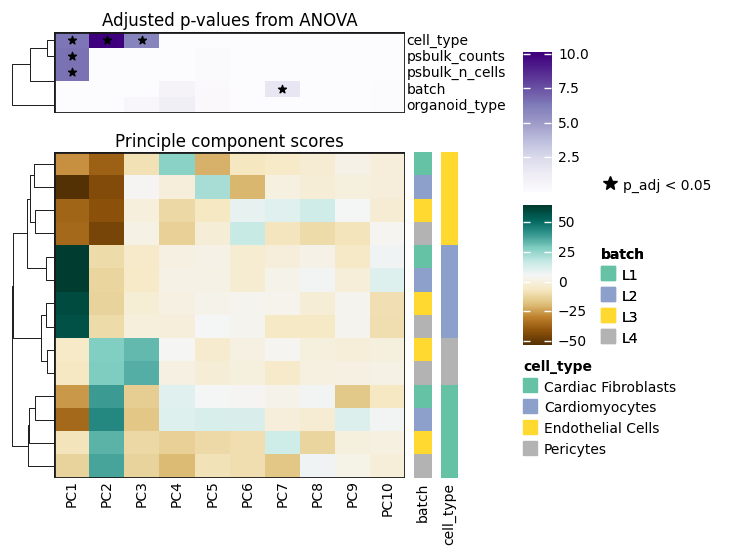

In [38]:
dc.plot_associations(
    pdata,
    uns_key='pca_anova',  # Summary statistics from the anova tests
    obsm_key='X_pca',  # where the PCs are stored
    stat_col='p_adj',  # Which summary statistic to plot
    obs_annotation_cols = ['batch', 'cell_type'], # which sample annotations to plot
    titles=['Principle component scores', 'Adjusted p-values from ANOVA'],
    figsize=(7, 5),
    n_factors=10,
)

In [39]:
organoid_bulk = pdata[pdata.obs].copy()
dc.plot_filter_by_expr(organoid_bulk, group='organoid_type', min_count=10, min_total_count=15)

IndexError: Unknown indexer                        batch            cell_type organoid_type  \
L1_Cardiac Fibroblasts    L1  Cardiac Fibroblasts   3 cell type   
L2_Cardiac Fibroblasts    L2  Cardiac Fibroblasts   3 cell type   
L3_Cardiac Fibroblasts    L3  Cardiac Fibroblasts   4 cell type   
L4_Cardiac Fibroblasts    L4  Cardiac Fibroblasts   4 cell type   
L1_Cardiomyocytes         L1       Cardiomyocytes   3 cell type   
L2_Cardiomyocytes         L2       Cardiomyocytes   3 cell type   
L3_Cardiomyocytes         L3       Cardiomyocytes   4 cell type   
L4_Cardiomyocytes         L4       Cardiomyocytes   4 cell type   
L1_Endothelial Cells      L1    Endothelial Cells   3 cell type   
L2_Endothelial Cells      L2    Endothelial Cells   3 cell type   
L3_Endothelial Cells      L3    Endothelial Cells   4 cell type   
L4_Endothelial Cells      L4    Endothelial Cells   4 cell type   
L3_Pericytes              L3            Pericytes   4 cell type   
L4_Pericytes              L4      

Pseudo-bulk profile gene filtering: Additional low quality sample filtering for downstream analysis such as DEA

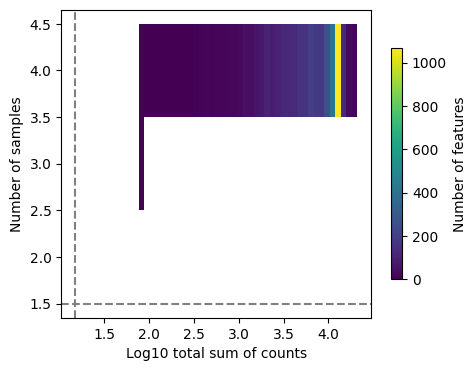

In [41]:
cardiomyocytes = pdata[pdata.obs['cell_type'] == 'Cardiomyocytes'].copy()
dc.plot_filter_by_expr(cardiomyocytes, group='organoid_type', min_count=10, min_total_count=15)

In [42]:
# Obtain genes that pass the thresholds
cmgenes = dc.filter_by_expr(cardiomyocytes, group='organoid_type', min_count=10, min_total_count=15)

# Filter by these genes
cardiomyocytes = cardiomyocytes[:, cmgenes].copy()
cardiomyocytes

AnnData object with n_obs × n_vars = 4 × 3797
    obs: 'batch', 'cell_type', 'organoid_type', 'psbulk_n_cells', 'psbulk_counts'
    var: 'mean', 'std'
    uns: 'log1p', 'pca', 'organoid_type_colors', 'cell_type_colors', 'pca_anova'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'psbulk_props', 'counts'

In [47]:
cardiomyocytes.layers

NameError: name 'counts' is not defined

In [30]:
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats
import numpy as np
import pandas as pd


In [31]:
# Build DESeq2 object
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    adata=cardiomyocytes,
    design_factors='organoid_type',
    ref_level= ['organoid_type', '3 cell type'],
    refit_cooks=True,
    inference=inference,
)

C:\Users\nateh\AppData\Local\Temp\ipykernel_17976\2663172241.py:3: UserWarning: Same factor names in the design contain underscores ('_'). They will
                be converted to hyphens ('-').
  dds = DeseqDataSet(


In [32]:
dds.deseq2()


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.00 seconds.

Fitting dispersion trend curve...
C:\Users\nateh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pydeseq2\dds.py:715: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.11 seconds.

C:\Users\nateh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pydeseq2\dds.py:490: UserWarning: As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.
  self.fit_dispersion_prior()
Fitting MAP dispersions...
... done in 1.20 seconds.

Fitting LFCs...
... done in 0.52 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replaci

In [33]:
# Extract contrast between 3 cell type vs 4 cell type
stat_res = DeseqStats(
    dds,
    contrast=["organoid-type", '4 cell type', '3 cell type'],
    inference=inference,
)

In [34]:
stat_res.summary()


Running Wald tests...


Log2 fold change & Wald test p-value: organoid-type 4 cell type vs 3 cell type
                baseMean  log2FoldChange     lfcSE      stat    pvalue  \
A1BG         2827.088166        0.016005  0.136340  0.117393  0.906548   
A1BG-AS1     1587.520543       -0.209986  0.192089 -1.093169  0.274319   
AAAS         3189.528644        0.095719  0.102778  0.931314  0.351691   
AACS         2247.291001        0.195098  0.183734  1.061850  0.288304   
AARS2        1526.655991       -0.405914  0.181067 -2.241783  0.024975   
...                  ...             ...       ...       ...       ...   
ZRSR2        3184.989969        0.016475  0.137905  0.119469  0.904903   
ZSCAN16-AS1  3249.784392        0.037574  0.128128  0.293253  0.769328   
ZSCAN18      3379.021720       -0.002147  0.109442 -0.019620  0.984346   
ZSCAN30      2527.025960       -0.066563  0.264363 -0.251787  0.801206   
ZWINT         469.284550        0.406681  0.190290  2.137170  0.032584   

                 padj  
A1BG    

... done in 0.27 seconds.



In [35]:
# Extract results
results_df = stat_res.results_df
results_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
A1BG,2827.088166,0.016005,0.136340,0.117393,0.906548,0.981328
A1BG-AS1,1587.520543,-0.209986,0.192089,-1.093169,0.274319,0.699711
AAAS,3189.528644,0.095719,0.102778,0.931314,0.351691,0.778628
AACS,2247.291001,0.195098,0.183734,1.061850,0.288304,0.715483
AARS2,1526.655991,-0.405914,0.181067,-2.241783,0.024975,0.149751
...,...,...,...,...,...,...
ZRSR2,3184.989969,0.016475,0.137905,0.119469,0.904903,0.981328
ZSCAN16-AS1,3249.784392,0.037574,0.128128,0.293253,0.769328,0.967332
ZSCAN18,3379.021720,-0.002147,0.109442,-0.019620,0.984346,0.996728
ZSCAN30,2527.025960,-0.066563,0.264363,-0.251787,0.801206,0.969539


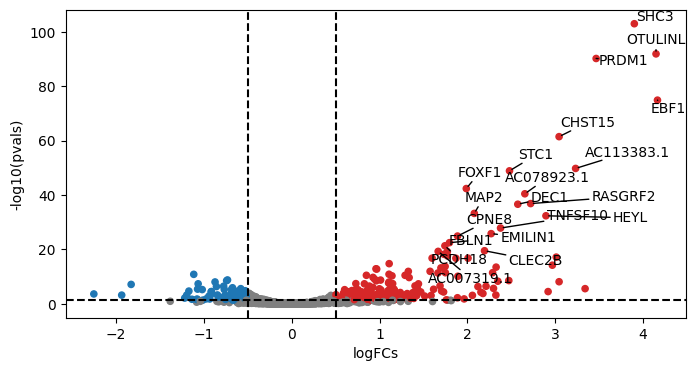

In [36]:
dc.plot_volcano_df(
    results_df,
    x='log2FoldChange',
    y='padj',
    top=20,
    figsize=(8, 4)
)

In [37]:
mat = results_df[['stat']].T.rename(index={'stat': 'Cardiomyocytes'})
mat

,A1BG,A1BG-AS1,AAAS,AACS,AARS2,ABCB6,ABCC4,ABCD1,ABCF1,ABCF2,...,ZNF852,ZNHIT3,ZNRD1,ZNRD2,ZPR1,ZRSR2,ZSCAN16-AS1,ZSCAN18,ZSCAN30,ZWINT
Cardiomyocytes,0.117393,-1.093169,0.931314,1.06185,-2.241783,-2.360458,5.12938,-0.40522,0.502831,0.216768,...,-0.679729,0.590769,0.512834,-1.443609,0.104837,0.119469,0.293253,-0.01962,-0.251787,2.13717


In [38]:
# Retrieve CollecTRI gene regulatory network
collectri = dc.get_collectri(organism='human', split_complexes=False)
collectri

,source,target,weight,PMID
0,MYC,TERT,1,10022128;10491298;10606235;10637317;10723141;1...
1,SPI1,BGLAP,1,10022617
2,SMAD3,JUN,1,10022869;12374795
3,SMAD4,JUN,1,10022869;12374795
4,STAT5A,IL2,1,10022878;11435608;17182565;17911616;22854263;2...
...,...,...,...,...
43173,NFKB,hsa-miR-143-3p,1,19472311
43174,AP1,hsa-miR-206,1,19721712
43175,NFKB,hsa-miR-21-5p,1,20813833;22387281
43176,NFKB,hsa-miR-224-5p,1,23474441;23988648


In [39]:
tf_acts, tf_pvals = dc.run_ulm(mat=mat, net=collectri)
tf_acts

,AHR,AIRE,AP1,APEX1,AR,ARNT,ARX,ASCL1,ASCL2,ATF1,...,ZGPAT,ZNF143,ZNF148,ZNF300,ZNF331,ZNF350,ZNF354C,ZNF384,ZNF699,ZNF91
Cardiomyocytes,2.76169,0.307007,3.8989,-0.608626,2.137079,1.077135,0.568077,0.287142,1.257001,1.834976,...,-2.840801,-0.327613,0.482702,-0.426289,0.391782,0.022575,1.386792,0.848389,0.123731,-0.40266


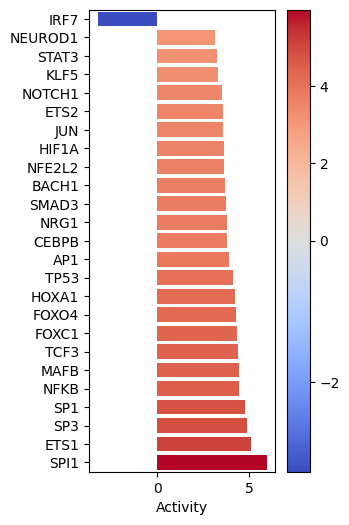

In [40]:
dc.plot_barplot(
    acts=tf_acts,
    contrast='Cardiomyocytes',
    top=25,
    vertical=True,
    figsize=(3, 6)
)

Activity Inference with Multivariate Linear Model (MLM) - this infers pathway enrichment scores

In [41]:
# Retrieve PROGENy model weights
progeny = dc.get_progeny(top=500)
progeny

,source,target,weight,p_value
0,Androgen,TMPRSS2,11.490631,0.000000e+00
1,Androgen,NKX3-1,10.622551,2.242078e-44
2,Androgen,MBOAT2,10.472733,4.624285e-44
3,Androgen,KLK2,10.176186,1.944414e-40
4,Androgen,SARG,11.386852,2.790209e-40
...,...,...,...,...
6995,p53,ZMYM4,-2.325752,1.522388e-06
6996,p53,CFDP1,-1.628168,1.526045e-06
6997,p53,VPS37D,2.309503,1.537098e-06
6998,p53,TEDC1,-2.274823,1.547037e-06


In [42]:
# Infer pathway activities with mlm
pathway_acts, pathway_pvals = dc.run_mlm(mat=mat, net=progeny)
pathway_acts

,Androgen,EGFR,Estrogen,Hypoxia,JAK-STAT,MAPK,NFkB,PI3K,TGFb,TNFa,Trail,VEGF,WNT,p53
Cardiomyocytes,3.351208,1.508371,-1.033707,3.493244,-0.541014,1.958868,-0.181077,1.433982,2.476983,1.242752,-0.164675,2.024243,-0.527302,0.846162


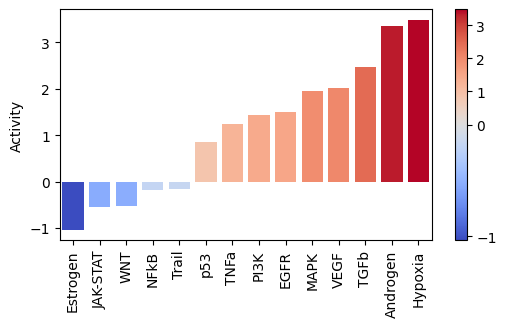

In [43]:
dc.plot_barplot(
    acts=pathway_acts,
    contrast='Cardiomyocytes',
    top=25,
    vertical=False,
    figsize=(6, 3)
)

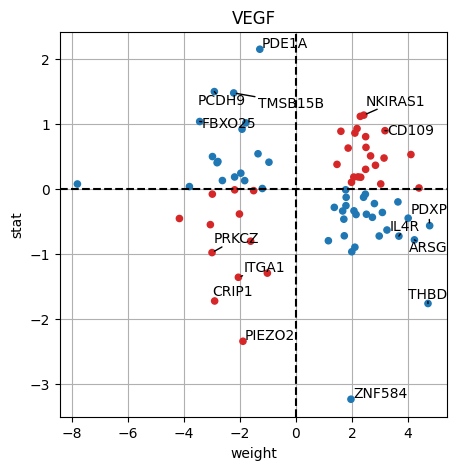

In [79]:
dc.plot_targets(
    data=results_df,
    stat='stat',
    source_name='VEGF',
    net=progeny,
    top=15
)

In [45]:
# Retrieve MSigDB resource
msigdb = dc.get_resource('MSigDB')
msigdb

,genesymbol,collection,geneset
0,MAFF,chemical_and_genetic_perturbations,BOYAULT_LIVER_CANCER_SUBCLASS_G56_DN
1,MAFF,chemical_and_genetic_perturbations,ELVIDGE_HYPOXIA_UP
2,MAFF,chemical_and_genetic_perturbations,NUYTTEN_NIPP1_TARGETS_DN
3,MAFF,immunesigdb,GSE17721_POLYIC_VS_GARDIQUIMOD_4H_BMDC_DN
4,MAFF,chemical_and_genetic_perturbations,SCHAEFFER_PROSTATE_DEVELOPMENT_12HR_UP
...,...,...,...
3838543,PRAMEF22,go_biological_process,GOBP_POSITIVE_REGULATION_OF_CELL_POPULATION_PR...
3838544,PRAMEF22,go_biological_process,GOBP_APOPTOTIC_PROCESS
3838545,PRAMEF22,go_biological_process,GOBP_REGULATION_OF_CELL_DEATH
3838546,PRAMEF22,go_biological_process,GOBP_NEGATIVE_REGULATION_OF_DEVELOPMENTAL_PROCESS


In [46]:
# Filter by hallmark
msigdb = msigdb[msigdb['collection']=='hallmark']

# Remove duplicated entries
msigdb = msigdb[~msigdb.duplicated(['geneset', 'genesymbol'])]

# Rename
msigdb.loc[:, 'geneset'] = [name.split('HALLMARK_')[1] for name in msigdb['geneset']]

msigdb

,genesymbol,collection,geneset
233,MAFF,hallmark,IL2_STAT5_SIGNALING
250,MAFF,hallmark,COAGULATION
270,MAFF,hallmark,HYPOXIA
373,MAFF,hallmark,TNFA_SIGNALING_VIA_NFKB
377,MAFF,hallmark,COMPLEMENT
...,...,...,...
1449668,STXBP1,hallmark,PANCREAS_BETA_CELLS
1450315,ELP4,hallmark,PANCREAS_BETA_CELLS
1450526,GCG,hallmark,PANCREAS_BETA_CELLS
1450731,PCSK2,hallmark,PANCREAS_BETA_CELLS


In [47]:
# Infer enrichment with ora using significant deg
top_genes = results_df[results_df['padj'] < 0.05]

# Run ora
enr_pvals = dc.get_ora_df(
    df=top_genes,
    net=msigdb,
    source='geneset',
    target='genesymbol'
)

enr_pvals.head()

,Term,Set size,Overlap ratio,p-value,FDR p-value,Odds ratio,Combined score,Features
0,ADIPOGENESIS,200,0.030000,0.238197,0.349851,1.563731,2.243420,ENPP2;MYLK;PPARG;REEP6;UCK1;UCP2
1,ALLOGRAFT_REJECTION,200,0.045000,0.024485,0.063933,2.302278,8.540733,CD40;EGFR;F2R;GBP2;IL11;IL4R;IL6;MMP9;TRAF2
2,ANDROGEN_RESPONSE,100,0.040000,0.155321,0.292004,2.160163,4.022785,ABCC4;ALDH1A3;AZGP1;NDRG1
3,ANGIOGENESIS,36,0.111111,0.006423,0.023222,5.966974,30.120511,LUM;MSX1;STC1;THBD
4,APICAL_JUNCTION,200,0.060000,0.001022,0.005338,3.051780,21.014081,ACTA1;ADAM15;AMH;CDH6;CLDN11;CLDN5;EGFR;FBN1;I...


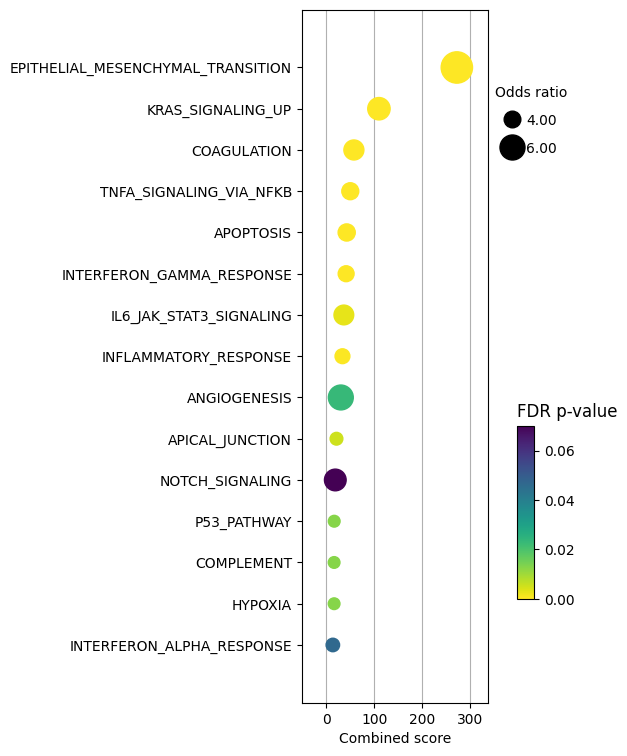

In [48]:
dc.plot_dotplot(
    enr_pvals.sort_values('Combined score', ascending=False).head(15),
    x='Combined score',
    y='Term',
    s='Odds ratio',
    c='FDR p-value',
    scale=0.5,
    figsize=(3, 9)
)

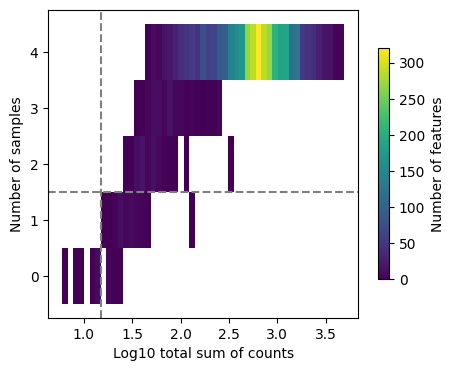

In [49]:
cFBs = pdata[pdata.obs['cell_type'] == 'Cardiac Fibroblasts'].copy()
dc.plot_filter_by_expr(cFBs, group='organoid_type', min_count=10, min_total_count=15)



In [50]:
# Obtain genes that pass the thresholds
cfbgenes = dc.filter_by_expr(cFBs, group='organoid_type', min_count=10, min_total_count=15)

# Filter by these genes
cFBs = cFBs[:, cfbgenes].copy()
cFBs

AnnData object with n_obs × n_vars = 4 × 3733
    obs: 'batch', 'cell_type', 'organoid_type', 'psbulk_n_cells', 'psbulk_counts'
    var: 'mean', 'std'
    uns: 'log1p', 'pca', 'organoid_type_colors', 'cell_type_colors', 'pca_anova'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'psbulk_props', 'counts'

In [51]:
# Build DESeq2 object
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    adata=cFBs,
    design_factors='organoid_type',
    ref_level= ['organoid_type', '3 cell type'],
    refit_cooks=True,
    inference=inference,
)

C:\Users\nateh\AppData\Local\Temp\ipykernel_17976\3087952963.py:3: UserWarning: Same factor names in the design contain underscores ('_'). They will
                be converted to hyphens ('-').
  dds = DeseqDataSet(


In [52]:
dds.deseq2()


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.82 seconds.

Fitting dispersion trend curve...
... done in 0.10 seconds.

C:\Users\nateh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pydeseq2\dds.py:490: UserWarning: As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.
  self.fit_dispersion_prior()
Fitting MAP dispersions...
... done in 0.97 seconds.

Fitting LFCs...
... done in 0.58 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.



In [53]:
# Extract contrast between 3 cell type vs 4 cell type
stat_res = DeseqStats(
    dds,
    contrast=["organoid-type", '4 cell type', '3 cell type'],
    inference=inference,
)

In [54]:
stat_res.summary()


Running Wald tests...


Log2 fold change & Wald test p-value: organoid-type 4 cell type vs 3 cell type
               baseMean  log2FoldChange     lfcSE      stat    pvalue  \
A1BG         440.060365        0.075894  0.225145  0.337088  0.736051   
A1BG-AS1     143.571656       -0.076097  0.304028 -0.250297  0.802358   
AAAS         144.450984        0.072748  0.308292  0.235970  0.813456   
AACS         139.382799       -0.348019  0.351973 -0.988764  0.322778   
AARS2         80.081365       -0.368988  0.428070 -0.861980  0.388699   
...                 ...             ...       ...       ...       ...   
ZRSR2        146.195447        0.742363  0.328677  2.258637  0.023906   
ZSCAN16-AS1  302.467995        0.362814  0.272428  1.331783  0.182931   
ZSCAN18      102.740201        0.617559  0.359889  1.715971  0.086167   
ZSCAN30       91.499372        0.765547  0.379635  2.016536  0.043744   
ZWINT         87.932723        0.402838  0.468180  0.860435  0.389549   

                 padj  
A1BG         0.91667

... done in 0.31 seconds.



In [55]:
# Extract results
results_df = stat_res.results_df
results_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
A1BG,440.060365,0.075894,0.225145,0.337088,0.736051,0.916678
A1BG-AS1,143.571656,-0.076097,0.304028,-0.250297,0.802358,0.937129
AAAS,144.450984,0.072748,0.308292,0.235970,0.813456,0.942117
AACS,139.382799,-0.348019,0.351973,-0.988764,0.322778,0.678561
AARS2,80.081365,-0.368988,0.428070,-0.861980,0.388699,0.727159
...,...,...,...,...,...,...
ZRSR2,146.195447,0.742363,0.328677,2.258637,0.023906,0.221069
ZSCAN16-AS1,302.467995,0.362814,0.272428,1.331783,0.182931,0.540373
ZSCAN18,102.740201,0.617559,0.359889,1.715971,0.086167,0.399287
ZSCAN30,91.499372,0.765547,0.379635,2.016536,0.043744,0.311868


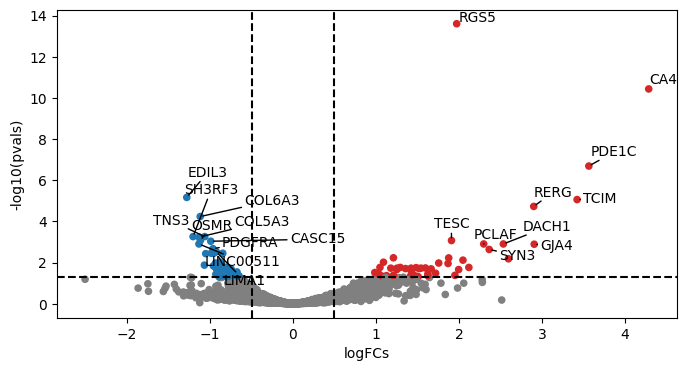

In [56]:
dc.plot_volcano_df(
    results_df,
    x='log2FoldChange',
    y='padj',
    top=20,
    figsize=(8, 4)
)

In [57]:
mat = results_df[['stat']].T.rename(index={'stat': 'Cardiac Fibroblasts'})
mat

,A1BG,A1BG-AS1,AAAS,AACS,AARS2,ABCB6,ABCC4,ABCD1,ABCF1,ABCF2,...,ZNF852,ZNHIT3,ZNRD1,ZNRD2,ZPR1,ZRSR2,ZSCAN16-AS1,ZSCAN18,ZSCAN30,ZWINT
Cardiac Fibroblasts,0.337088,-0.250297,0.23597,-0.988764,-0.86198,-2.458555,-3.73273,1.770114,0.192417,0.704051,...,0.097241,0.97161,1.096732,-0.238606,-0.319343,2.258637,1.331783,1.715971,2.016536,0.860435


In [58]:
tf_acts, tf_pvals = dc.run_ulm(mat=mat, net=collectri)
tf_acts

,AHR,AIRE,AP1,APEX1,AR,ARNT,ARX,ASCL1,ASCL2,ATF1,...,ZGPAT,ZNF143,ZNF148,ZNF300,ZNF331,ZNF350,ZNF354C,ZNF384,ZNF699,ZNF91
Cardiac Fibroblasts,-4.093886,-0.686172,-3.176114,-1.376501,-0.247112,-2.484654,0.740343,0.85046,1.434448,-1.01,...,-0.278166,-0.140653,-0.5274,-1.324429,-1.106897,0.696478,-3.823555,-1.962526,-0.108989,1.07131


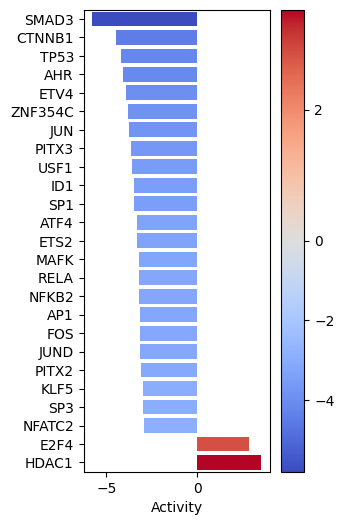

In [59]:
dc.plot_barplot(
    acts=tf_acts,
    contrast='Cardiac Fibroblasts',
    top=25,
    vertical=True,
    figsize=(3, 6)
)

In [60]:
# Infer pathway activities with mlm
pathway_acts, pathway_pvals = dc.run_mlm(mat=mat, net=progeny)
pathway_acts

,Androgen,EGFR,Estrogen,Hypoxia,JAK-STAT,MAPK,NFkB,PI3K,TGFb,TNFa,Trail,VEGF,WNT,p53
Cardiac Fibroblasts,-1.970632,-1.88753,0.934645,-3.799594,1.323562,-0.790678,-2.07458,-2.816732,-4.69952,-0.088224,1.31047,-3.496874,1.501983,0.005259


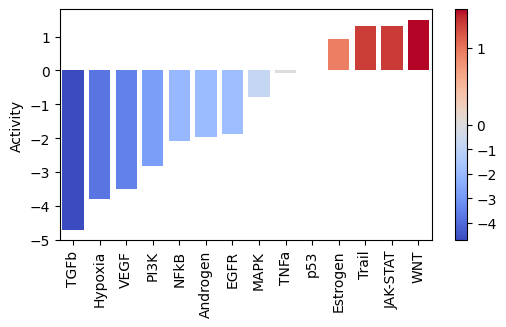

In [61]:
dc.plot_barplot(
    acts=pathway_acts,
    contrast='Cardiac Fibroblasts',
    top=25,
    vertical=False,
    figsize=(6, 3)
)

In [62]:
# Infer enrichment with ora using significant deg
top_genes = results_df[results_df['padj'] < 0.05]

# Run ora
enr_pvals = dc.get_ora_df(
    df=top_genes,
    net=msigdb,
    source='geneset',
    target='genesymbol'
)

enr_pvals.head()

,Term,Set size,Overlap ratio,p-value,FDR p-value,Odds ratio,Combined score,Features
0,ADIPOGENESIS,200,0.015000,0.080753,0.136005,3.509083,8.830119,CD36;MIGA2;SLC1A5
1,ALLOGRAFT_REJECTION,200,0.005000,0.638554,0.638554,1.473964,0.661145,F2R
2,ANDROGEN_RESPONSE,100,0.010000,0.398025,0.471734,2.955447,2.722675,ABCC4
3,ANGIOGENESIS,36,0.055556,0.014227,0.049802,13.743030,58.443683,COL5A2;S100A4
4,APICAL_JUNCTION,200,0.010000,0.267935,0.342956,2.481297,3.267899,ATP1A3;LIMA1


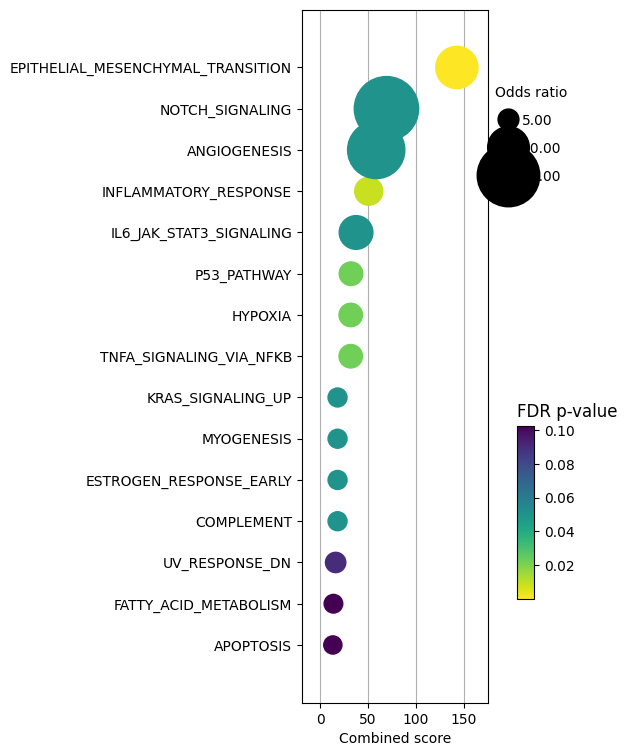

In [63]:
dc.plot_dotplot(
    enr_pvals.sort_values('Combined score', ascending=False).head(15),
    x='Combined score',
    y='Term',
    s='Odds ratio',
    c='FDR p-value',
    scale=0.5,
    figsize=(3, 9)
)

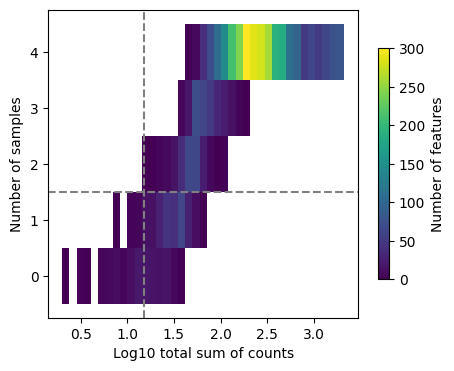

In [64]:
ECs = pdata[pdata.obs['cell_type'] == 'Endothelial Cells'].copy()
dc.plot_filter_by_expr(ECs, group='organoid_type', min_count=10, min_total_count=15)



In [65]:
# Obtain genes that pass the thresholds
ecgenes = dc.filter_by_expr(ECs, group='organoid_type', min_count=10, min_total_count=15)

# Filter by these genes
ECs = ECs[:, ecgenes].copy()
ECs

AnnData object with n_obs × n_vars = 4 × 3417
    obs: 'batch', 'cell_type', 'organoid_type', 'psbulk_n_cells', 'psbulk_counts'
    var: 'mean', 'std'
    uns: 'log1p', 'pca', 'organoid_type_colors', 'cell_type_colors', 'pca_anova'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'psbulk_props', 'counts'

In [66]:
# Build DESeq2 object
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    adata=ECs,
    design_factors='organoid_type',
    ref_level= ['organoid_type', '3 cell type'],
    refit_cooks=True,
    inference=inference,
)

C:\Users\nateh\AppData\Local\Temp\ipykernel_17976\3504823096.py:3: UserWarning: Same factor names in the design contain underscores ('_'). They will
                be converted to hyphens ('-').
  dds = DeseqDataSet(


In [67]:
dds.deseq2()
# Extract contrast between 3 cell type vs 4 cell type
stat_res = DeseqStats(
    dds,
    contrast=["organoid-type", '4 cell type', '3 cell type'],
    inference=inference,
)
stat_res.summary()


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.74 seconds.

Fitting dispersion trend curve...
C:\Users\nateh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pydeseq2\dds.py:715: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.10 seconds.

C:\Users\nateh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pydeseq2\dds.py:490: UserWarning: As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.
  self.fit_dispersion_prior()
Fitting MAP dispersions...
... done in 0.87 seconds.

Fitting LFCs...
... done in 0.47 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replaci

Log2 fold change & Wald test p-value: organoid-type 4 cell type vs 3 cell type
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG         42.152421       -0.093693  0.531065 -0.176425  0.859960  0.999934
A1BG-AS1     43.429460       -0.926601  0.535844 -1.729236  0.083767  0.999934
AAAS         38.673225        0.203618  0.519532  0.391926  0.695113  0.999934
AACS         67.931667        0.210295  0.492393  0.427087  0.669316  0.999934
AARS2        26.746416       -0.061027  0.643370 -0.094855  0.924430  0.999934
...                ...             ...       ...       ...       ...       ...
ZPR1         49.968686        0.347450  0.526825  0.659518  0.509563  0.999934
ZRSR2        97.120308        0.031018  0.456450  0.067955  0.945822  0.999934
ZSCAN16-AS1  24.903673        0.700743  0.591066  1.185558  0.235797  0.999934
ZSCAN18      56.689518       -0.400303  0.506291 -0.790659  0.429143  0.999934
ZSCAN30      58.753596       -0.128046  0.656689 -0.

... done in 0.30 seconds.



In [68]:
# Extract results
results_df = stat_res.results_df
results_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
A1BG,42.152421,-0.093693,0.531065,-0.176425,0.859960,0.999934
A1BG-AS1,43.429460,-0.926601,0.535844,-1.729236,0.083767,0.999934
AAAS,38.673225,0.203618,0.519532,0.391926,0.695113,0.999934
AACS,67.931667,0.210295,0.492393,0.427087,0.669316,0.999934
AARS2,26.746416,-0.061027,0.643370,-0.094855,0.924430,0.999934
...,...,...,...,...,...,...
ZPR1,49.968686,0.347450,0.526825,0.659518,0.509563,0.999934
ZRSR2,97.120308,0.031018,0.456450,0.067955,0.945822,0.999934
ZSCAN16-AS1,24.903673,0.700743,0.591066,1.185558,0.235797,0.999934
ZSCAN18,56.689518,-0.400303,0.506291,-0.790659,0.429143,0.999934


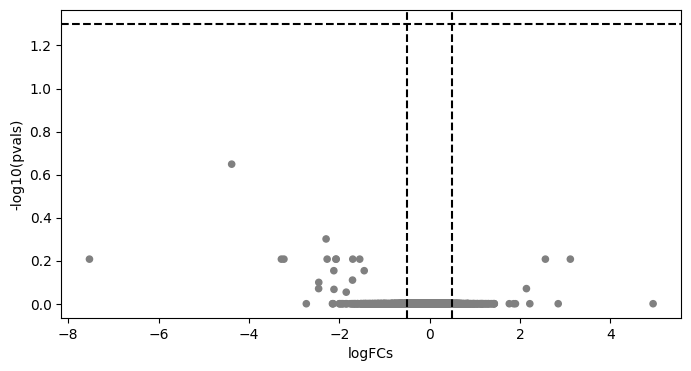

In [69]:
dc.plot_volcano_df(
    results_df,
    x='log2FoldChange',
    y='padj',
    top=20,
    figsize=(8, 4)
)

In [70]:
mat = results_df[['stat']].T.rename(index={'stat': 'Endothelial Cells'})
mat

,A1BG,A1BG-AS1,AAAS,AACS,AARS2,ABCB6,ABCC4,ABCD1,ABCF1,ABCF2,...,ZNF846,ZNF852,ZNHIT3,ZNRD1,ZNRD2,ZPR1,ZRSR2,ZSCAN16-AS1,ZSCAN18,ZSCAN30
Endothelial Cells,-0.176425,-1.729236,0.391926,0.427087,-0.094855,1.789916,-0.499964,0.587927,-0.613782,0.352441,...,0.032542,0.289411,-0.341868,-0.00926,-0.132908,0.659518,0.067955,1.185558,-0.790659,-0.194988


In [71]:
tf_acts, tf_pvals = dc.run_ulm(mat=mat, net=collectri)
tf_acts

,AHR,AP1,APEX1,AR,ARNT,ARX,ASCL1,ASCL2,ATF1,ATF2,...,ZFP42,ZNF143,ZNF148,ZNF300,ZNF331,ZNF350,ZNF354C,ZNF384,ZNF699,ZNF91
Endothelial Cells,-2.639936,-1.722923,-0.354362,-2.576504,-1.890851,-0.038136,-0.105411,-0.289656,-1.585814,-1.489657,...,-0.785995,1.587519,0.981271,-1.16892,-1.041364,-0.584323,0.679618,-0.426351,0.965887,-1.144828


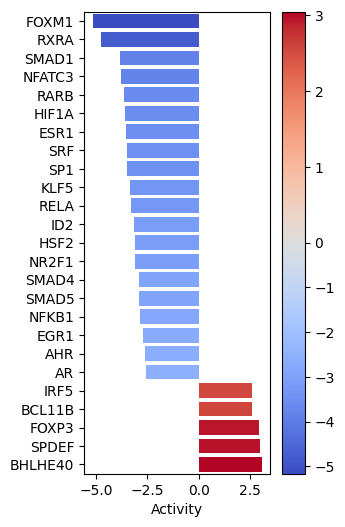

In [72]:
dc.plot_barplot(
    acts=tf_acts,
    contrast='Endothelial Cells',
    top=25,
    vertical=True,
    figsize=(3, 6)
)

In [73]:
# Infer pathway activities with mlm
pathway_acts, pathway_pvals = dc.run_mlm(mat=mat, net=progeny)
pathway_acts

,Androgen,EGFR,Estrogen,Hypoxia,JAK-STAT,MAPK,NFkB,PI3K,TGFb,TNFa,Trail,VEGF,WNT,p53
Endothelial Cells,-0.978969,-1.692169,1.315893,-1.998862,-2.509052,1.523406,-1.435936,-0.778483,-3.97939,0.643839,-1.404818,-0.829828,0.077061,1.534407


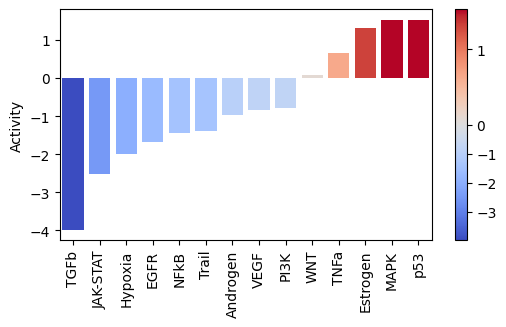

In [74]:
dc.plot_barplot(
    acts=pathway_acts,
    contrast='Endothelial Cells',
    top=25,
    vertical=False,
    figsize=(6, 3)
)

In [75]:
# Infer enrichment with ora using significant deg
top_genes = results_df[results_df['padj'] < 0.05]

# Run ora
enr_pvals = dc.get_ora_df(
    df=top_genes,
    net=msigdb,
    source='geneset',
    target='genesymbol'
)

enr_pvals.head()

,Term,Set size,Overlap ratio,p-value,FDR p-value,Odds ratio,Combined score,Features


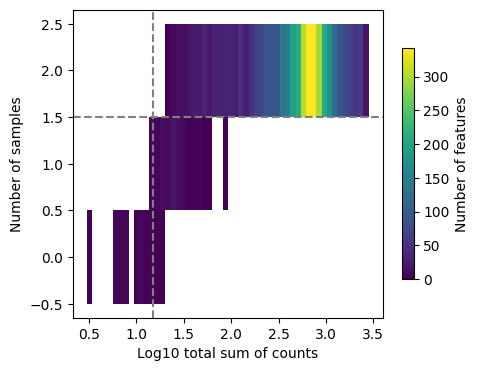

In [76]:
pericytes = pdata[pdata.obs['cell_type'] == 'Pericytes'].copy()
dc.plot_filter_by_expr(pericytes, group='organoid_type', min_count=10, min_total_count=15)



In [77]:
# Obtain genes that pass the thresholds
pcgenes = dc.filter_by_expr(pericytes, group='organoid_type', min_count=10, min_total_count=15)

# Filter by these genes
pericytes = pericytes[:, pcgenes].copy()
pericytes

AnnData object with n_obs × n_vars = 2 × 3683
    obs: 'batch', 'cell_type', 'organoid_type', 'psbulk_n_cells', 'psbulk_counts'
    var: 'mean', 'std'
    uns: 'log1p', 'pca', 'organoid_type_colors', 'cell_type_colors', 'pca_anova'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'psbulk_props', 'counts'

In [78]:
# Build DESeq2 object
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    adata=pericytes,
    design_factors='organoid_type',
    ref_level= ['organoid_type', '4 cell type'],
    refit_cooks=True,
    inference=inference,
)

C:\Users\nateh\AppData\Local\Temp\ipykernel_17976\3363535686.py:3: UserWarning: Same factor names in the design contain underscores ('_'). They will
                be converted to hyphens ('-').
  dds = DeseqDataSet(


ValueError: Factors should take at least two values, but organoid-type takes the single value '['4 cell type']'.

In [80]:
dds.deseq2()
# Extract contrast between 3 cell type vs 4 cell type
stat_res = DeseqStats(
    dds,
    contrast=["organoid-type", '4 cell type', '3 cell type'],
    inference=inference,
)
stat_res.summary()


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.73 seconds.

Fitting dispersion trend curve...
C:\Users\nateh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pydeseq2\dds.py:715: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.10 seconds.

C:\Users\nateh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pydeseq2\dds.py:490: UserWarning: As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.
  self.fit_dispersion_prior()
Fitting MAP dispersions...
... done in 0.86 seconds.

Fitting LFCs...
... done in 0.47 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replaci

Log2 fold change & Wald test p-value: organoid-type 4 cell type vs 3 cell type
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG         42.152421       -0.093693  0.531065 -0.176425  0.859960  0.999934
A1BG-AS1     43.429460       -0.926601  0.535844 -1.729236  0.083767  0.999934
AAAS         38.673225        0.203618  0.519532  0.391926  0.695113  0.999934
AACS         67.931667        0.210295  0.492393  0.427087  0.669316  0.999934
AARS2        26.746416       -0.061027  0.643370 -0.094855  0.924430  0.999934
...                ...             ...       ...       ...       ...       ...
ZPR1         49.968686        0.347450  0.526825  0.659518  0.509563  0.999934
ZRSR2        97.120308        0.031018  0.456450  0.067955  0.945822  0.999934
ZSCAN16-AS1  24.903673        0.700743  0.591066  1.185558  0.235797  0.999934
ZSCAN18      56.689518       -0.400303  0.506291 -0.790659  0.429143  0.999934
ZSCAN30      58.753596       -0.128046  0.656689 -0.

... done in 0.24 seconds.



In [81]:
# Extract results
results_df = stat_res.results_df
results_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
A1BG,42.152421,-0.093693,0.531065,-0.176425,0.859960,0.999934
A1BG-AS1,43.429460,-0.926601,0.535844,-1.729236,0.083767,0.999934
AAAS,38.673225,0.203618,0.519532,0.391926,0.695113,0.999934
AACS,67.931667,0.210295,0.492393,0.427087,0.669316,0.999934
AARS2,26.746416,-0.061027,0.643370,-0.094855,0.924430,0.999934
...,...,...,...,...,...,...
ZPR1,49.968686,0.347450,0.526825,0.659518,0.509563,0.999934
ZRSR2,97.120308,0.031018,0.456450,0.067955,0.945822,0.999934
ZSCAN16-AS1,24.903673,0.700743,0.591066,1.185558,0.235797,0.999934
ZSCAN18,56.689518,-0.400303,0.506291,-0.790659,0.429143,0.999934


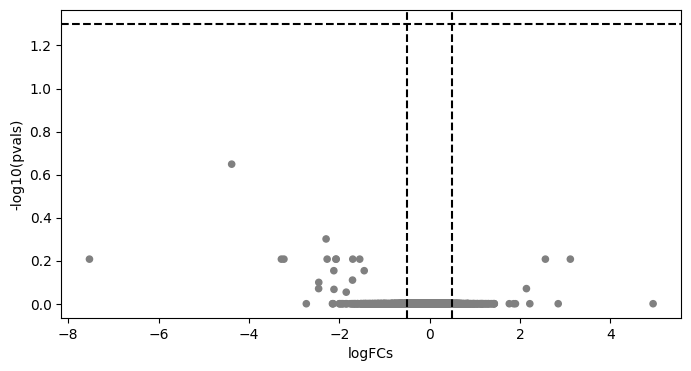

In [82]:
dc.plot_volcano_df(
    results_df,
    x='log2FoldChange',
    y='padj',
    top=20,
    figsize=(8, 4)
)

In [83]:
mat = results_df[['stat']].T.rename(index={'stat': 'Pericytes'})
mat

tf_acts, tf_pvals = dc.run_ulm(mat=mat, net=collectri)
tf_acts

,AHR,AP1,APEX1,AR,ARNT,ARX,ASCL1,ASCL2,ATF1,ATF2,...,ZFP42,ZNF143,ZNF148,ZNF300,ZNF331,ZNF350,ZNF354C,ZNF384,ZNF699,ZNF91
Pericytes,-2.639936,-1.722923,-0.354362,-2.576504,-1.890851,-0.038136,-0.105411,-0.289656,-1.585814,-1.489657,...,-0.785995,1.587519,0.981271,-1.16892,-1.041364,-0.584323,0.679618,-0.426351,0.965887,-1.144828


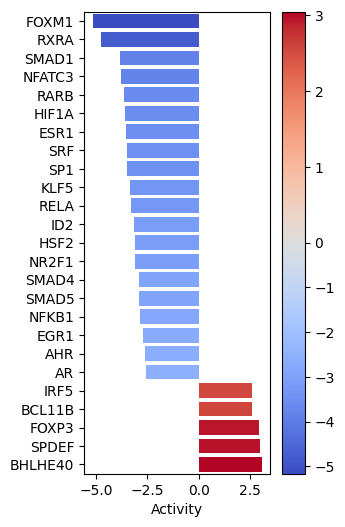

In [84]:
dc.plot_barplot(
    acts=tf_acts,
    contrast='Pericytes',
    top=25,
    vertical=True,
    figsize=(3, 6)
)

In [85]:
# Infer pathway activities with mlm
pathway_acts, pathway_pvals = dc.run_mlm(mat=mat, net=progeny)
pathway_acts

,Androgen,EGFR,Estrogen,Hypoxia,JAK-STAT,MAPK,NFkB,PI3K,TGFb,TNFa,Trail,VEGF,WNT,p53
Pericytes,-0.978969,-1.692169,1.315893,-1.998862,-2.509052,1.523406,-1.435936,-0.778483,-3.97939,0.643839,-1.404818,-0.829828,0.077061,1.534407


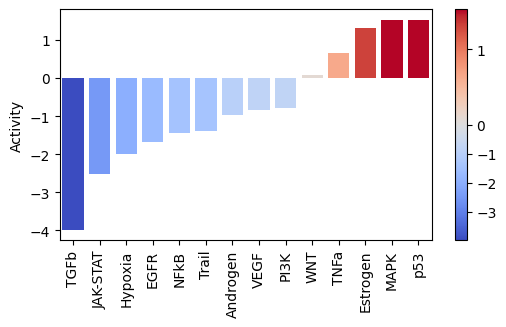

In [86]:
dc.plot_barplot(
    acts=pathway_acts,
    contrast='Pericytes',
    top=25,
    vertical=False,
    figsize=(6, 3)
)

In [87]:
# Infer enrichment with ora using significant deg
top_genes = results_df[results_df['padj'] < 0.05]

# Run ora
enr_pvals = dc.get_ora_df(
    df=top_genes,
    net=msigdb,
    source='geneset',
    target='genesymbol'
)

enr_pvals.head()

,Term,Set size,Overlap ratio,p-value,FDR p-value,Odds ratio,Combined score,Features


ValueError: s must be a scalar, or float array-like with the same size as x and y

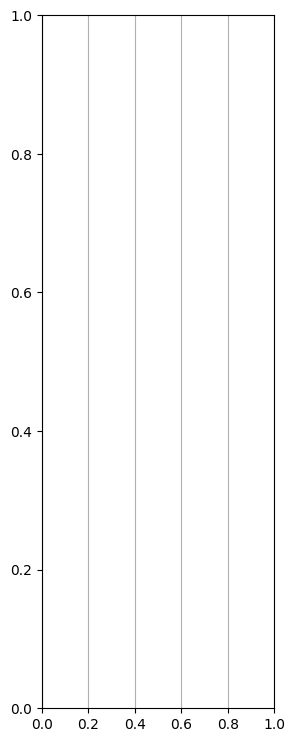

In [88]:
dc.plot_dotplot(
    enr_pvals.sort_values('Combined score', ascending=False).head(15),
    x='Combined score',
    y='Term',
    s='Odds ratio',
    c='FDR p-value',
    scale=0.5,
    figsize=(3, 9)
)